In [ ]:
!pip install kagglehub

import kagglehub
import os

# Set token langsung
os.environ["KAGGLE_TOKEN"] = "token_baru_kamu_disini"

# Download dataset
path = kagglehub.dataset_download("dhruvmak/font-recognition-data")
print("Path to dataset files:", path)

100%|██████████| 1.27G/1.27G [00:13<00:00, 101MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dhruvmak/font-recognition-data/versions/1


In [ ]:
import os

# Cek path dataset
print("Path:", path)

# Lihat isi folder
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Tampilkan 2 level saja
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Max 5 file per folder
            print(f'{subindent}{file}')

Path: /root/.cache/kagglehub/datasets/dhruvmak/font-recognition-data/versions/1
1/
  Font Dataset Large/
    Corbel/
    Comic Sans MS/
    Helvetica/
    Agency/
    Sabon/
    Steppes TT/
    Century/
    Akzidenz Grotesk/
    Book Antiqua/
    Perpetua/
    Nasalization/
    Snowdrift Regular/
    Candara/
    Fascinate/
    Monotype Corsiva/
    Myriad/
    Lucida Bright/
    News Gothic/
    Georgia/
    Frutiger/
    Franklin Gothic/
    Courier/
    Futura/
    Algerian/
    Calligraphy/
    LCD Mono/
    Didot/
    Bodoni/
    Mrs Eaves/
    Hombre/
    Elephant/
    Times New Roman/
    Minion/
    Californian FB/
    Consolas/
    Garamond/
    Arial/
    Palatino linotype/
    Bembo/
    Calibry/
    Brandish/
    Verdana/
    Bell MT/
    Calvin/
    Baskerville/
    Cambria/
    Rockwell/
    Gill sans/
  Font Dataset Large Color/
    Corbel/
    Comic Sans MS/
    Helvetica/
    Agency/
    Sabon/
    Steppes TT/
    Century/
    Akzidenz Grotesk/
    Book Antiqua/
    Pe

In [ ]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.models import Sequential

In [ ]:
# Cek path hasil download tadi
print(path)

/root/.cache/kagglehub/datasets/dhruvmak/font-recognition-data/versions/1


In [ ]:
# Set directory dataset
directory = '/root/.cache/kagglehub/datasets/dhruvmak/font-recognition-data/versions/1'

# Lihat isi folder
for item in os.listdir(directory):
    print(item)

Font Dataset Large
Font Dataset Large Color


In [ ]:
# Set path ke folder yang akan dipakai
font_path = directory + '/Font Dataset Large'

# Lihat isi foldernya
for item in os.listdir(font_path):
    print(item)

Corbel
Comic Sans MS
Helvetica
Agency
Sabon
Steppes TT
Century
Akzidenz Grotesk
Book Antiqua
Perpetua
Nasalization
Snowdrift Regular
Candara
Fascinate
Monotype Corsiva
Myriad
Lucida Bright
News Gothic
Georgia
Frutiger
Franklin Gothic
Courier
Futura
Algerian
Calligraphy
LCD Mono
Didot
Bodoni
Mrs Eaves
Hombre
Elephant
Times New Roman
Minion
Californian FB
Consolas
Garamond
Arial
Palatino linotype
Bembo
Calibry
Brandish
Verdana
Bell MT
Calvin
Baskerville
Cambria
Rockwell
Gill sans


In [ ]:
# Set path ke 4 font yang dipakai
arial_path = font_path + '/Arial'
brandish_path = font_path + '/Brandish'
consolas_path = font_path + '/Consolas'
didot_path = font_path + '/Didot'

# Cek isi masing-masing (5 file pertama)
arial_filenames = os.listdir(arial_path)
print("Arial:", arial_filenames[:5])

Arial: ['Image_4555.jpg', 'Image_611.jpg', 'Image_223.jpg', 'Image_1214.jpg', 'Image_4397.jpg']


In [ ]:
def load_image(filenames, path):
    images = []
    for filename in tqdm(filenames):
        image = cv2.imread(path + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)
    return images

# Load gambar dari 4 folder
brandish_filenames = os.listdir(brandish_path)
consolas_filenames = os.listdir(consolas_path)
didot_filenames = os.listdir(didot_path)

arial_images = load_image(arial_filenames, arial_path)
brandish_images = load_image(brandish_filenames, brandish_path)
consolas_images = load_image(consolas_filenames, consolas_path)
didot_images = load_image(didot_filenames, didot_path)

100%|██████████| 5000/5000 [00:00<00:00, 9609.24it/s]


In [ ]:
# Cek ukuran gambar
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]
    heights.append(height)
    widths.append(width)

print("max_h:", max(heights), "min_h:", min(heights))
print("max_w:", max(widths), "min_w:", min(widths))

max_h: 32 min_h: 32
max_w: 248 min_w: 30


In [ ]:
def take_80_pixels(images_list):
    new_images = []
    for image in images_list:
        if image.shape[1] >= 80:
            new_images.append(image[:, :80])
        else:
            pass
    return np.array(new_images)

# Apply ke semua font
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

# Cek shape hasilnya
print(arial_80.shape)
print(brandish_80.shape)
print(consolas_80.shape)
print(didot_80.shape)

(4079, 32, 80)
(4028, 32, 80)
(4741, 32, 80)
(3920, 32, 80)


In [ ]:
# Gabungkan semua gambar
all_images = np.append(arial_80, brandish_80, axis=0)
all_images = np.append(all_images, consolas_80, axis=0)
all_images = np.append(all_images, didot_80, axis=0)

# Reshape untuk input CNN (tambah channel dimension)
all_images = all_images.reshape(all_images.shape[0],
                                 all_images.shape[1],
                                 all_images.shape[2], 1)

print(all_images.shape)

(16768, 32, 80, 1)


In [ ]:
# Buat label untuk setiap font
labels = [0]*len(arial_80) + \
         [1]*len(brandish_80) + \
         [2]*len(consolas_80) + \
         [3]*len(didot_80)

labels = np.array(labels)
print(len(labels))

16768


In [ ]:
# Split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    all_images,
    labels,
    test_size=0.3,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (11737, 32, 80, 1)
X_test: (5031, 32, 80, 1)
y_train: (11737,)
y_test: (5031,)


In [ ]:
# Konversi label ke one-hot encoding
one_hot_encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = one_hot_encoder.transform(y_test.reshape(-1, 1))

print(y_train_encoded[:5])

[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


In [ ]:
# Buat model CNN
input_shape = (all_images.shape[1], all_images.shape[2], 1)

model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(98, kernel_size=(3,3), activation='relu', padding='same'))
model.add(Conv2D(4, kernel_size=(3,3), activation='softmax'))
model.add(Flatten())
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 40, 98)     │        56,546 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 38, 4)      │         3,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2128)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,430 (341.52 KB)

 Trainable params: 87,430 (341.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['acc'])

# Training model
history = model.fit(X_train, y_train_encoded,
                    epochs=3,
                    validation_data=(X_test, y_test_encoded))

Epoch 1/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 232s 623ms/step - acc: 0.2827 - loss: 1.3849 - val_acc: 0.2819 - val_loss: 1.3837
Epoch 2/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 223s 609ms/step - acc: 0.2831 - loss: 1.3836 - val_acc: 0.2819 - val_loss: 1.3835
Epoch 3/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 226s 617ms/step - acc: 0.2831 - loss: 1.3835 - val_acc: 0.2819 - val_loss: 1.3836


In [ ]:
# Rebuild model yang lebih baik
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(98, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 20, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 98)             │     1,003,618 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,830 (3.90 MB)

 Trainable params: 1,022,830 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model baru
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['acc'])

# Training model
history = model.fit(X_train, y_train_encoded,
                    epochs=3,
                    validation_data=(X_test, y_test_encoded))

Epoch 1/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - acc: 0.9577 - loss: 2.6103 - val_acc: 0.9966 - val_loss: 0.0141
Epoch 2/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 54s 147ms/step - acc: 0.9923 - loss: 0.0261 - val_acc: 0.9986 - val_loss: 0.0083
Epoch 3/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 87s 160ms/step - acc: 0.9963 - loss: 0.0117 - val_acc: 0.9986 - val_loss: 0.0072


158/158 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step


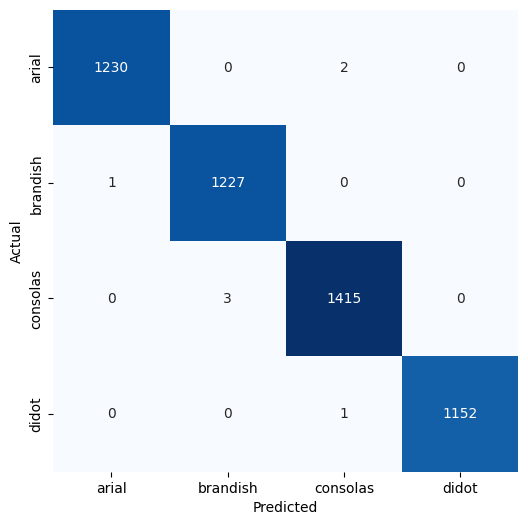

In [ ]:
# Prediksi data test
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

# Ubah y_test ke 1 dimensi
y_test_1d = y_test.reshape(-1)

# Buat confusion matrix
label_names = ['arial', 'brandish', 'consolas', 'didot']
cm = confusion_matrix(y_test_1d, predictions)

# Tampilkan confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Cari indeks misklasifikasi
misses = []
for i in range(len(predictions)):
    if y_test[i] == predictions[i]:
        misses.append(i)

print(misses)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [ ]:
# Cari indeks misklasifikasi (yang SALAH)
misses = []
for i in range(len(predictions)):
    if y_test[i] != predictions[i]:
        misses.append(i)

print(misses)

[916, 1458, 1573, 2155, 4504, 4698, 4975]


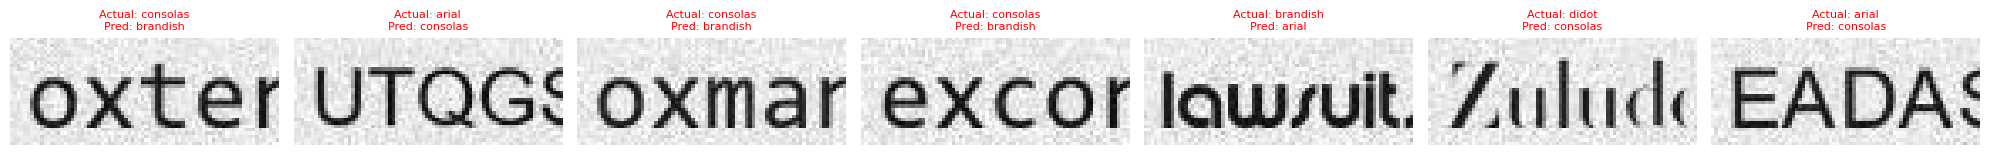

In [ ]:
# Tampilkan foto yang salah diprediksi
label_names = ['arial', 'brandish', 'consolas', 'didot']

fig, axes = plt.subplots(1, 7, figsize=(20, 3))
for i, miss in enumerate(misses):
    axes[i].imshow(X_test[miss].reshape(32, 80), cmap='gray')
    actual = label_names[y_test[miss]]
    predicted = label_names[predictions[miss]]
    axes[i].set_title(f'Actual: {actual}\nPred: {predicted}', color='red', fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()